In [343]:
import pandas as pd
import numpy as np

In [344]:
!head -n 10 babynames/yob1880.txt

Mary,F,7065
Anna,F,2604
Emma,F,2003
Elizabeth,F,1939
Minnie,F,1746
Margaret,F,1578
Ida,F,1472
Alice,F,1414
Bertha,F,1320
Sarah,F,1288


In [345]:
names1880 = pd.read_csv("babynames/yob1880.txt",
names=["name", "sex", "births"])

In [346]:
names1880

,name,sex,births
0,Mary,F,7065
1,Anna,F,2604
2,Emma,F,2003
3,Elizabeth,F,1939
4,Minnie,F,1746
...,...,...,...
1995,Woodie,M,5
1996,Worthy,M,5
1997,Wright,M,5
1998,York,M,5


In [347]:
# sum of the births column by sex 
names1880.groupby("sex")["births"].sum()

sex
F     90993
M    110493
Name: births, dtype: int64

In [348]:
# assemble all of the data into a single DataFrame
pieces = []
for year in range(1880, 2011):
    path = f"babynames/yob{year}.txt"
    frame = pd.read_csv(path, names=["name", "sex", "births"])
    
    # Add a column for the year
    frame["year"] = year
    pieces.append(frame)

In [349]:
# Concatenate everything into a single DataFrame
names = pd.concat(pieces, ignore_index=True)

In [350]:
names

,name,sex,births,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880
...,...,...,...,...
1690779,Zymaire,M,5,2010
1690780,Zyonne,M,5,2010
1690781,Zyquarius,M,5,2010
1690782,Zyran,M,5,2010


In [351]:
total_births = names.pivot_table("births", index="year",
                                columns="sex", aggfunc=sum)

In [352]:
total_births.tail()

sex,F,M
year,,
2006,1896468,2050234
2007,1916888,2069242
2008,1883645,2032310
2009,1827643,1973359
2010,1759010,1898382


<Axes: title={'center': 'Total births by sex and year'}, xlabel='year'>

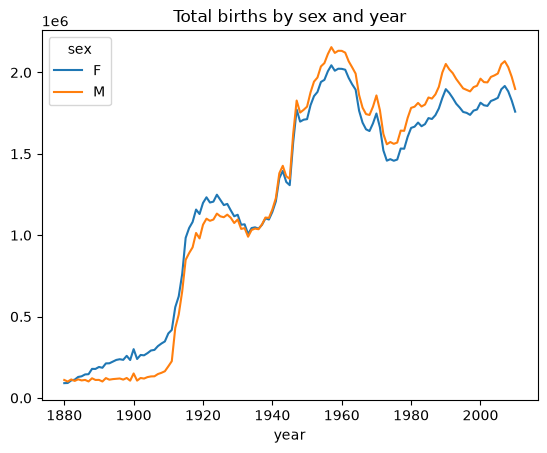

In [353]:
total_births.plot(title="Total births by sex and year")

In [354]:
def add_prop(group):
    group["prop"] = group["births"] / group["births"].sum()
    return group
    
names = names.groupby(["year", "sex"]).apply(add_prop)

In [355]:
names

name  births      prop
year sex                                     
1880 F   0             Mary    7065  0.077643
         1             Anna    2604  0.028618
         2             Emma    2003  0.022013
         3        Elizabeth    1939  0.021309
         4           Minnie    1746  0.019188
...                     ...     ...       ...
2010 M   1690779    Zymaire       5  0.000003
         1690780     Zyonne       5  0.000003
         1690781  Zyquarius       5  0.000003
         1690782      Zyran       5  0.000003
         1690783      Zzyzx       5  0.000003

[1690784 rows x 3 columns]

In [356]:
names = names.reset_index()
 
print(names.columns)

Index(['year', 'sex', 'level_2', 'name', 'births', 'prop'], dtype='str')


In [357]:
names = names.drop(columns=["level_2"])

In [366]:
print(names.columns)

Index(['year', 'sex', 'name', 'births', 'prop'], dtype='str')


In [367]:
names.groupby(["year", "sex"])["prop"].sum()

year  sex
1880  F      1.0
      M      1.0
1881  F      1.0
      M      1.0
1882  F      1.0
            ... 
2008  M      1.0
2009  F      1.0
      M      1.0
2010  F      1.0
      M      1.0
Name: prop, Length: 262, dtype: float64

In [369]:
def get_top1000(group):
    return group.sort_values("births", ascending=False)[:1000]

top1000 = []
for (year, sex), group in names.groupby(["year", "sex"]):
    top1000.append(get_top1000(group))

top1000 = pd.concat(top1000, ignore_index=True)

print(top1000.columns)
print(top1000.head())

Index(['year', 'sex', 'name', 'births', 'prop'], dtype='str')
   year sex       name  births      prop
0  1880   F       Mary    7065  0.077643
1  1880   F       Anna    2604  0.028618
2  1880   F       Emma    2003  0.022013
3  1880   F  Elizabeth    1939  0.021309
4  1880   F     Minnie    1746  0.019188


In [370]:
boys = top1000[top1000["sex"] == "M"]
girls = top1000[top1000["sex"] == "F"]

In [371]:
total_births = top1000.pivot_table("births", index="year",
                                    columns="name",
                                    aggfunc=sum)

In [372]:
 total_births.info()

<class 'pandas.DataFrame'>
Index: 131 entries, 1880 to 2010
Columns: 6862 entries, Aaden to Zuri
dtypes: float64(6862)
memory usage: 6.9 MB


In [373]:
subset = total_births[["John", "Harry", "Mary", "Marilyn"]]

array([<Axes: xlabel='year'>, <Axes: xlabel='year'>,
       <Axes: xlabel='year'>, <Axes: xlabel='year'>], dtype=object)

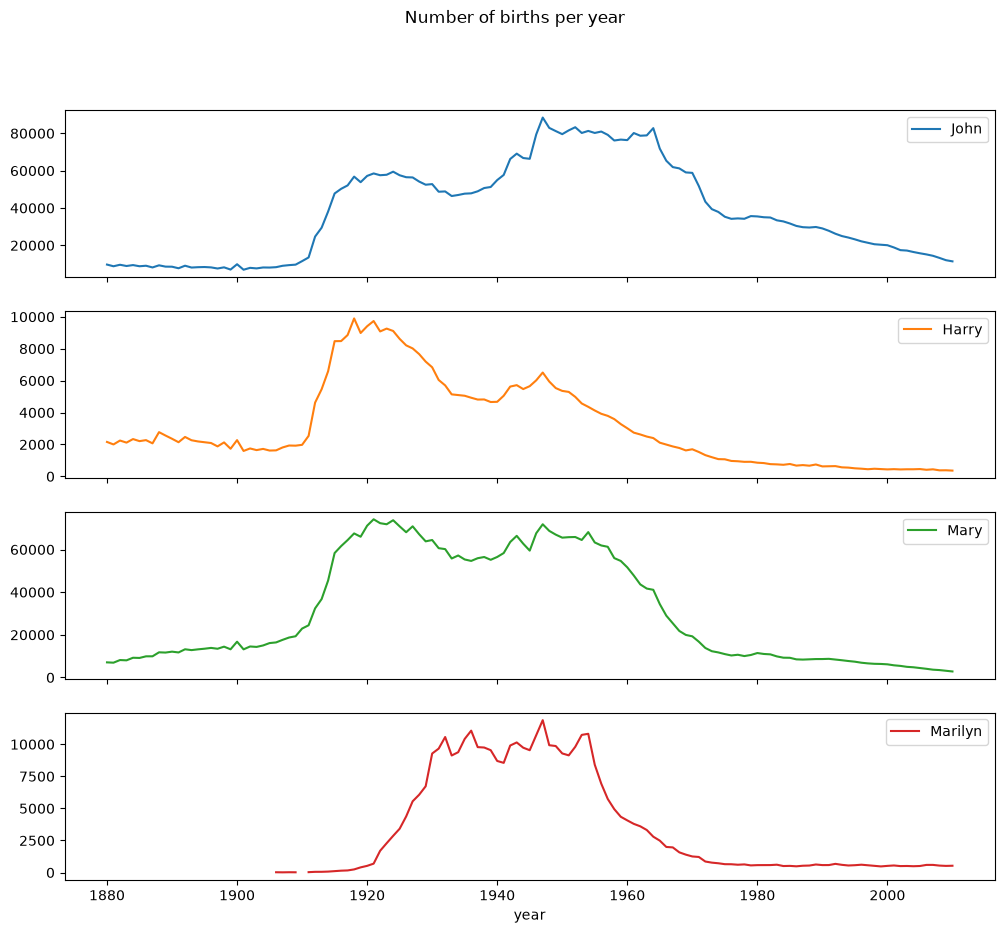

In [374]:
subset.plot(subplots=True, figsize=(12, 10),
            title="Number of births per year")

In [375]:
table = top1000.pivot_table("prop", index="year",
                            columns="sex", aggfunc=sum)

<Axes: title={'center': 'Sum of table1000.prop by year and sex'}, xlabel='year'>

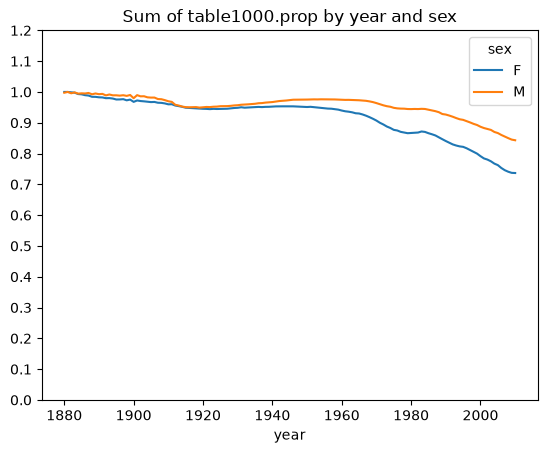

In [376]:
table.plot(title="Sum of table1000.prop by year and sex",
                    yticks=np.linspace(0, 1.2, 13))

In [377]:
df = boys[boys["year"] == 2010]

In [379]:
df

,year,sex,name,births,prop
260877,2010,M,Jacob,21875,0.011523
260878,2010,M,Ethan,17866,0.009411
260879,2010,M,Michael,17133,0.009025
260880,2010,M,Jayden,17030,0.008971
260881,2010,M,William,16870,0.008887
...,...,...,...,...,...
261872,2010,M,Camilo,194,0.000102
261873,2010,M,Destin,194,0.000102
261874,2010,M,Jaquan,194,0.000102
261875,2010,M,Jaydan,194,0.000102


In [380]:
prop_cumsum = df["prop"].sort_values(ascending=False).cumsum()

In [381]:
prop_cumsum[:10]

260877    0.011523
260878    0.020934
260879    0.029959
260880    0.038930
260881    0.047817
260882    0.056579
260883    0.065155
260884    0.073414
260885    0.081528
260886    0.089621
Name: prop, dtype: float64